# Hotel Recommendation System — Composite Scoring
**ICOICT 2026 Travlr Data Challenge**  
Joyce Stephanie Naibaho | Institut Teknologi Del  
Dataset: 55,000+ Accommodation Metadata

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
print("Libraries loaded successfully!")

Libraries loaded successfully!


## 2. Load Dataset

In [2]:
from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f"File uploaded: {filename}")

Saving Dataset_55k_new.xlsx to Dataset_55k_new.xlsx
File uploaded: Dataset_55k_new.xlsx


In [3]:
df_meta     = pd.read_excel(filename, sheet_name='accommodation metadata dataset')
df_activity = pd.read_excel(filename, sheet_name='activity dataset')
df_trans    = pd.read_excel(filename, sheet_name='accommodation transactions data')

print(f"Accommodation Metadata   : {len(df_meta):,} rows")
print(f"Activity Dataset         : {len(df_activity):,} rows")
print(f"Accommodation Transaction: {len(df_trans):,} rows")

Accommodation Metadata   : 55,133 rows
Activity Dataset         : 15,000 rows
Accommodation Transaction: 3,734 rows


## 3. Data Preprocessing

In [4]:
for col in ['guest_rating_score', 'popularity_score', 'price_in_aud', 'guest_rating_count']:
    df_meta[col] = pd.to_numeric(df_meta[col], errors='coerce')

df_valid = df_meta[
    (df_meta['guest_rating_score'] >= 0) &
    (df_meta['guest_rating_score'] <= 100) &
    (df_meta['price_in_aud'] > 0) &
    (df_meta['popularity_score'] >= 100)
].dropna(subset=['guest_rating_score', 'popularity_score', 'guest_rating_count']).copy().reset_index(drop=True)

print(f"Total data (before filter): {len(df_meta):,}")
print(f"Total data (after filter) : {len(df_valid):,}")
print()
print("Filtering criteria:")
print("  - guest_rating_score >= 0 and <= 100  (remove outliers > 100)")
print("  - price_in_aud > 0                    (remove zero/missing price)")
print("  - popularity_score >= 100             (remove outliers 1-3)")
print("  - popularity_score, guest_rating_count: not NaN")

Total data (before filter): 55,133
Total data (after filter) : 11,061

Filtering criteria:
  - guest_rating_score >= 0 and <= 100  (remove outliers > 100)
  - price_in_aud > 0                    (remove zero/missing price)
  - popularity_score >= 100             (remove outliers 1-3)
  - popularity_score, guest_rating_count: not NaN


In [5]:
def minmax(s):
    mn, mx = s.min(), s.max()
    return (s - mn) / (mx - mn) if mx != mn else pd.Series([0.5]*len(s), index=s.index)

df_valid['norm_pop']    = minmax(df_valid['popularity_score'])
df_valid['norm_rating'] = minmax(df_valid['guest_rating_score'])
df_valid['norm_review'] = minmax(df_valid['guest_rating_count'])
df_valid['norm_price']  = minmax(df_valid['price_in_aud'])

print("Min-Max Normalization done!")
df_valid[['guest_rating_score','norm_rating','popularity_score','norm_pop',
          'guest_rating_count','norm_review','price_in_aud','norm_price']].head()

Min-Max Normalization done!


,guest_rating_score,norm_rating,popularity_score,norm_pop,guest_rating_count,norm_review,price_in_aud,norm_price
0,90.0,0.871795,101.9758,0.955839,443.0,0.016127,172.03,0.005188
1,94.0,0.923077,101.9130,0.841241,70.0,0.002518,245.51,0.007495
2,92.0,0.897436,101.9809,0.965146,425.0,0.015471,332.47,0.010224
3,86.0,0.820513,101.9865,0.975365,1001.0,0.036487,125.99,0.003743
4,90.0,0.871795,101.8781,0.777555,415.0,0.015106,107.99,0.003178


## 4. Join Metadata + Transaction

In [6]:
trans_agg = df_trans.groupby('Product')['Number Transactions'].sum().reset_index()
trans_agg.columns = ['name', 'num_transactions']

df_valid['name_clean']  = df_valid['name'].str.lower().str.strip()
trans_agg['name_clean'] = trans_agg['name'].str.lower().str.strip()

merged_raw = df_valid.merge(trans_agg, on='name_clean', how='inner')
print(f"Unique hotels in transaction : {len(trans_agg):,}")
print(f"Before deduplication         : {len(merged_raw)} rows")
print(f"Duplicates found             : {len(merged_raw) - merged_raw['name_x'].nunique()}")

merged = merged_raw.groupby('name_x', as_index=False).agg(
    guest_rating_score=('guest_rating_score', 'first'),
    popularity_score=('popularity_score', 'first'),
    guest_rating_count=('guest_rating_count', 'first'),
    price_in_aud=('price_in_aud', 'first'),
    num_transactions=('num_transactions', 'sum')
).reset_index(drop=True)

print(f"After deduplication          : {len(merged)} hotels")
display(merged[['name_x', 'guest_rating_score', 'popularity_score',
                'guest_rating_count', 'price_in_aud', 'num_transactions']])

Unique hotels in transaction : 2,536
Before deduplication         : 141 rows
Duplicates found             : 7
After deduplication          : 134 hotels


,name_x,guest_rating_score,popularity_score,guest_rating_count,price_in_aud,num_transactions
0,ADGE Hotel & Residences,92.0,101.9539,872.0,180.83,1
1,Adelaide Inn,82.0,101.9409,999.0,137.98,1
2,Alex Beach Cabins,90.0,101.8974,997.0,176.00,1
3,Amora Hotel Jamison Sydney,90.0,101.9993,1458.0,243.46,11
4,Apollo Hotel,74.0,101.9824,985.0,74.36,1
...,...,...,...,...,...,...
129,Wollongbar Motel,86.0,101.9081,774.0,212.59,1
130,Wollongong Surf Leisure Resort,88.0,101.8615,525.0,165.54,1
131,Wynn Las Vegas,92.0,102.0000,9870.0,202.65,1
132,ibis Styles Kingsgate,80.0,101.9987,1001.0,79.96,5


## 5. Spearman Correlation

In [7]:
print("=" * 60)
print(f"Spearman Correlation vs num_transactions (n={len(merged)})")
print("=" * 60)

indicators = {
    'guest_rating_score': 'Rating',
    'popularity_score'  : 'Popularity',
    'guest_rating_count': 'Review Count',
    'price_in_aud'      : 'Price'
}

results = []
for col, name in indicators.items():
    corr, pval = spearmanr(merged[col], merged['num_transactions'])
    results.append({
        'Indicator'           : name,
        'Spearman Correlation': round(corr, 4),
        'p-value'             : round(pval, 4),
        'Significant (p<0.05)': '✅ Yes' if pval < 0.05 else '❌ No'
    })
    print(f"{name:<15}: corr = {round(corr,4):>8}, p-value = {round(pval,4)}")

df_corr = pd.DataFrame(results)
print(f"\nTotal hotels used: {len(merged)}")
df_corr

Spearman Correlation vs num_transactions (n=134)
Rating         : corr =   0.1142, p-value = 0.1889
Popularity     : corr =   0.2398, p-value = 0.0053
Review Count   : corr =   0.1926, p-value = 0.0258
Price          : corr =   0.1157, p-value = 0.1832

Total hotels used: 134


,Indicator,Spearman Correlation,p-value,Significant (p<0.05)
0,Rating,0.1142,0.1889,❌ No
1,Popularity,0.2398,0.0053,✅ Yes
2,Review Count,0.1926,0.0258,✅ Yes
3,Price,0.1157,0.1832,❌ No


## 6. AHP Weights

In [8]:
corr_values = {row['Indicator']: row['Spearman Correlation'] for _, row in df_corr.iterrows()}
sum_abs = sum(abs(v) for v in corr_values.values())
print(f"Sum Absolute = {round(sum_abs, 4)}\n")

names = list(corr_values.keys())
weights_raw = [abs(corr_values[n]) / sum_abs for n in names]

weight_data = []
for i, (name, w_raw) in enumerate(zip(names, weights_raw)):
    if i < len(names) - 1:
        w = round(w_raw, 3)
    else:
        w = round(1 - sum(round(weights_raw[j], 3) for j in range(len(names)-1)), 3)
    weight_data.append({'Indicator': name, 'Correlation': corr_values[name], 'Spearman Weight': w})
    print(f"{name:<15}: {round(abs(corr_values[name]),4)} / {round(sum_abs,4)} = {w}")

df_weights = pd.DataFrame(weight_data)
print(f"\nTotal weight: {sum(r['Spearman Weight'] for r in weight_data)}")
df_weights

Sum Absolute = 0.6623

Rating         : 0.1142 / 0.6623 = 0.172
Popularity     : 0.2398 / 0.6623 = 0.362
Review Count   : 0.1926 / 0.6623 = 0.291
Price          : 0.1157 / 0.6623 = 0.175

Total weight: 1.0


,Indicator,Correlation,Spearman Weight
0,Rating,0.1142,0.172
1,Popularity,0.2398,0.362
2,Review Count,0.1926,0.291
3,Price,0.1157,0.175


## 7. Define Ground Truth

In [9]:
avg_rating = df_valid['guest_rating_score'].mean()
avg_review = df_valid['guest_rating_count'].mean()

df_valid['relevant'] = (
    (df_valid['guest_rating_score'] > avg_rating) &
    (df_valid['guest_rating_count'] > avg_review)
).astype(int)

print(f"Average guest_rating_score : {avg_rating:.2f}")
print(f"Average guest_rating_count : {avg_review:.2f}")
print(f"Relevant hotels            : {df_valid['relevant'].sum():,} out of {len(df_valid):,}")
print(f"Percentage                 : {df_valid['relevant'].mean()*100:.1f}%")

Average guest_rating_score : 83.44
Average guest_rating_count : 574.44
Relevant hotels            : 3,313 out of 11,061
Percentage                 : 30.0%


## 8. Implementation of 11 Composite Scoring Models

In [10]:
w = {row['Indicator']: row['Spearman Weight'] for _, row in df_weights.iterrows()}

# Bobot 3 ind (RC+Price+Rating)
s3_old = w['Review Count'] + w['Price'] + w['Rating']
w3_rc_old = round(w['Review Count']/s3_old, 3)
w3_pr_old = round(w['Price']/s3_old, 3)
w3_rt_old = round(1 - w3_rc_old - w3_pr_old, 3)

# Bobot 2 ind (RC+Price)
s2_old = w['Review Count'] + w['Price']
w2_rc_old = round(w['Review Count']/s2_old, 3)
w2_pr_old = round(1 - w2_rc_old, 3)

# Bobot 2 ind (Pop+RC)
s2_new = w['Popularity'] + w['Review Count']
w2_pop_new = round(w['Popularity']/s2_new, 3)
w2_rc_new  = round(1 - w2_pop_new, 3)

# Bobot 3 ind (Pop+RC+Price)
s3_new = w['Popularity'] + w['Review Count'] + w['Price']
w3_pop_new = round(w['Popularity']/s3_new, 3)
w3_rc_new  = round(w['Review Count']/s3_new, 3)
w3_pr_new  = round(1 - w3_pop_new - w3_rc_new, 3)

print("=== Weights Used ===")
print(f"AHP 4 ind           → Rating:{w['Rating']}, Pop:{w['Popularity']}, RC:{w['Review Count']}, Price:{w['Price']}")
print(f"AHP 3 ind (RC+P+R)  → RC:{w3_rc_old}, Price:{w3_pr_old}, Rating:{w3_rt_old}")
print(f"AHP 2 ind (RC+P)    → RC:{w2_rc_old}, Price:{w2_pr_old}")
print(f"AHP 2 ind (Pop+RC)  → Pop:{w2_pop_new}, RC:{w2_rc_new}")
print(f"AHP 3 ind (Pop+RC+P)→ Pop:{w3_pop_new}, RC:{w3_rc_new}, Price:{w3_pr_new}")
print()
print("Comparison: Old vs New Weights")
print(f"{'Indicator':<15} {'Old Weight':>12} {'New Weight (AHP)':>18}")
print("-" * 47)
old_w = {'Rating': 0.30, 'Popularity': 0.30, 'Review Count': 0.30, 'Price': 0.10}
for name in ['Rating', 'Popularity', 'Review Count', 'Price']:
    print(f"{name:<15} {old_w[name]:>12} {w[name]:>18}")

# ── Single Dimension ──
df_valid['cs_popularity'] = df_valid['norm_pop']
df_valid['cs_rating']     = df_valid['norm_rating']
df_valid['cs_review']     = df_valid['norm_review']
df_valid['cs_price']      = 1 - df_valid['norm_price']

# ── Multi Dimension ──
df_valid['cs_original']  = (0.3*df_valid['norm_pop'] + 0.3*df_valid['norm_rating'] +
                             0.3*df_valid['norm_review'] + 0.1*(1-df_valid['norm_price']))
df_valid['cs_equal']     = (0.25*df_valid['norm_pop'] + 0.25*df_valid['norm_rating'] +
                             0.25*df_valid['norm_review'] + 0.25*(1-df_valid['norm_price']))
df_valid['cs_ahp4']      = (w['Popularity']*df_valid['norm_pop'] + w['Rating']*df_valid['norm_rating'] +
                             w['Review Count']*df_valid['norm_review'] + w['Price']*(1-df_valid['norm_price']))
df_valid['cs_ahp3_old']  = (w3_rc_old*df_valid['norm_review'] + w3_pr_old*(1-df_valid['norm_price']) +
                             w3_rt_old*df_valid['norm_rating'])
df_valid['cs_ahp2_old']  = (w2_rc_old*df_valid['norm_review'] + w2_pr_old*(1-df_valid['norm_price']))
df_valid['cs_ahp2_new']  = (w2_pop_new*df_valid['norm_pop'] + w2_rc_new*df_valid['norm_review'])
df_valid['cs_ahp3_new']  = (w3_pop_new*df_valid['norm_pop'] + w3_rc_new*df_valid['norm_review'] +
                             w3_pr_new*(1-df_valid['norm_price']))

print("\n11 models computed successfully!")

=== Weights Used ===
AHP 4 ind           → Rating:0.172, Pop:0.362, RC:0.291, Price:0.175
AHP 3 ind (RC+P+R)  → RC:0.456, Price:0.274, Rating:0.27
AHP 2 ind (RC+P)    → RC:0.624, Price:0.376
AHP 2 ind (Pop+RC)  → Pop:0.554, RC:0.446
AHP 3 ind (Pop+RC+P)→ Pop:0.437, RC:0.351, Price:0.212

Comparison: Old vs New Weights
Indicator         Old Weight   New Weight (AHP)
-----------------------------------------------
Rating                   0.3              0.172
Popularity               0.3              0.362
Review Count             0.3              0.291
Price                    0.1              0.175

11 models computed successfully!


In [12]:
# Rename CS columns to Spearman naming
df_valid = df_valid.rename(columns={
    'cs_ahp4'     : 'cs_spearman4',
    'cs_ahp3_old' : 'cs_spearman3_old',
    'cs_ahp2_old' : 'cs_spearman2_old',
    'cs_ahp2_new' : 'cs_spearman2_new',
    'cs_ahp3_new' : 'cs_spearman3_new',
})
print("Columns renamed successfully!")
print(df_valid[['cs_spearman4','cs_spearman3_old','cs_spearman2_old','cs_spearman2_new','cs_spearman3_new']].head(3))

Columns renamed successfully!
   cs_spearman4  cs_spearman3_old  cs_spearman2_old  cs_spearman2_new  \
0      0.674748          0.515317          0.384113          0.536728   
1      0.637719          0.522325          0.374753          0.467170   
2      0.681455          0.520561          0.381809          0.541591   

   cs_spearman3_new  
0          0.634263  
1          0.578917  
2          0.637031  


## 9. Evaluation — Precision@K, Recall@K, NDCG@K

In [13]:
def evaluate(scores, relevant, k_list=[5,10,20]):
    ranked = np.argsort(scores)[::-1]
    results = {}
    for k in k_list:
        top_k    = ranked[:k]
        rel_in_k = relevant[top_k].sum()
        precision = rel_in_k / k
        recall    = rel_in_k / relevant.sum()
        dcg  = sum(relevant[top_k[i]] / np.log2(i+2) for i in range(k))
        ideal = sorted(relevant, reverse=True)[:k]
        idcg = sum(ideal[i] / np.log2(i+2) for i in range(k))
        ndcg = dcg/idcg if idcg > 0 else 0
        results[k] = {'P': round(precision,4), 'R': round(recall,4), 'NDCG': round(ndcg,4)}
    return results

rel = df_valid['relevant'].values

models = {
    'CS Popularity Only'             : df_valid['cs_popularity'].values,
    'CS Rating Only'                 : df_valid['cs_rating'].values,
    'CS Review Count Only'           : df_valid['cs_review'].values,
    'CS Price Only'                  : df_valid['cs_price'].values,
    'CS Original (0.3/0.3/0.3/0.1)' : df_valid['cs_original'].values,
    'CS Equal Weight (0.25 each)'    : df_valid['cs_equal'].values,
    'CS Spearman 4 Indicators'            : df_valid['cs_spearman4'].values,
    'CS Spearman 3 Ind (RC+P+R)' : df_valid['cs_spearman3_old'].values,
    'CS Spearman 2 Ind (RC+P)'        : df_valid['cs_spearman2_old'].values,
    'CS Spearman 2 Ind (Pop+RC)'          : df_valid['cs_spearman2_new'].values,
    'CS Spearman 3 Ind (Pop+RC+P)'    : df_valid['cs_spearman3_new'].values,
}

eval_results = []
for model_name, scores in models.items():
    res = evaluate(scores, rel)
    eval_results.append({
        'Model'   : model_name,
        'P@5'     : res[5]['P'],  'R@5'    : res[5]['R'],  'NDCG@5' : res[5]['NDCG'],
        'P@10'    : res[10]['P'], 'R@10'   : res[10]['R'], 'NDCG@10': res[10]['NDCG'],
        'P@20'    : res[20]['P'], 'R@20'   : res[20]['R'], 'NDCG@20': res[20]['NDCG'],
    })

df_eval = pd.DataFrame(eval_results)
print("=== Evaluation Results ===")
display(df_eval)

=== Evaluation Results ===


,Model,P@5,R@5,NDCG@5,P@10,R@10,NDCG@10,P@20,R@20,NDCG@20
0,CS Popularity Only,0.8,0.0012,0.8304,0.5,0.0015,0.6122,0.55,0.0033,0.6010
1,CS Rating Only,0.0,0.0000,0.0000,0.2,0.0006,0.1357,0.10,0.0006,0.0876
2,CS Review Count Only,0.4,0.0006,0.3836,0.4,0.0012,0.3820,0.50,0.0030,0.4612
3,CS Price Only,0.2,0.0003,0.1696,0.1,0.0003,0.1100,0.05,0.0003,0.0710
4,CS Original (0.3/0.3/0.3/0.1),0.6,0.0009,0.6548,0.5,0.0015,0.5580,0.75,0.0045,0.7147
5,CS Equal Weight (0.25 each),0.6,0.0009,0.6548,0.5,0.0015,0.5619,0.75,0.0045,0.7173
6,CS Spearman 4 Indicators,0.4,0.0006,0.5087,0.5,0.0015,0.5384,0.70,0.0042,0.6637
7,CS Spearman 3 Ind (RC+P+R),0.4,0.0006,0.5087,0.5,0.0015,0.5384,0.65,0.0039,0.6314
8,CS Spearman 2 Ind (RC+P),0.4,0.0006,0.3601,0.4,0.0012,0.3667,0.50,0.0030,0.4513
9,CS Spearman 2 Ind (Pop+RC),0.4,0.0006,0.3836,0.4,0.0012,0.3820,0.55,0.0033,0.4919


## 10. Visualization of Results

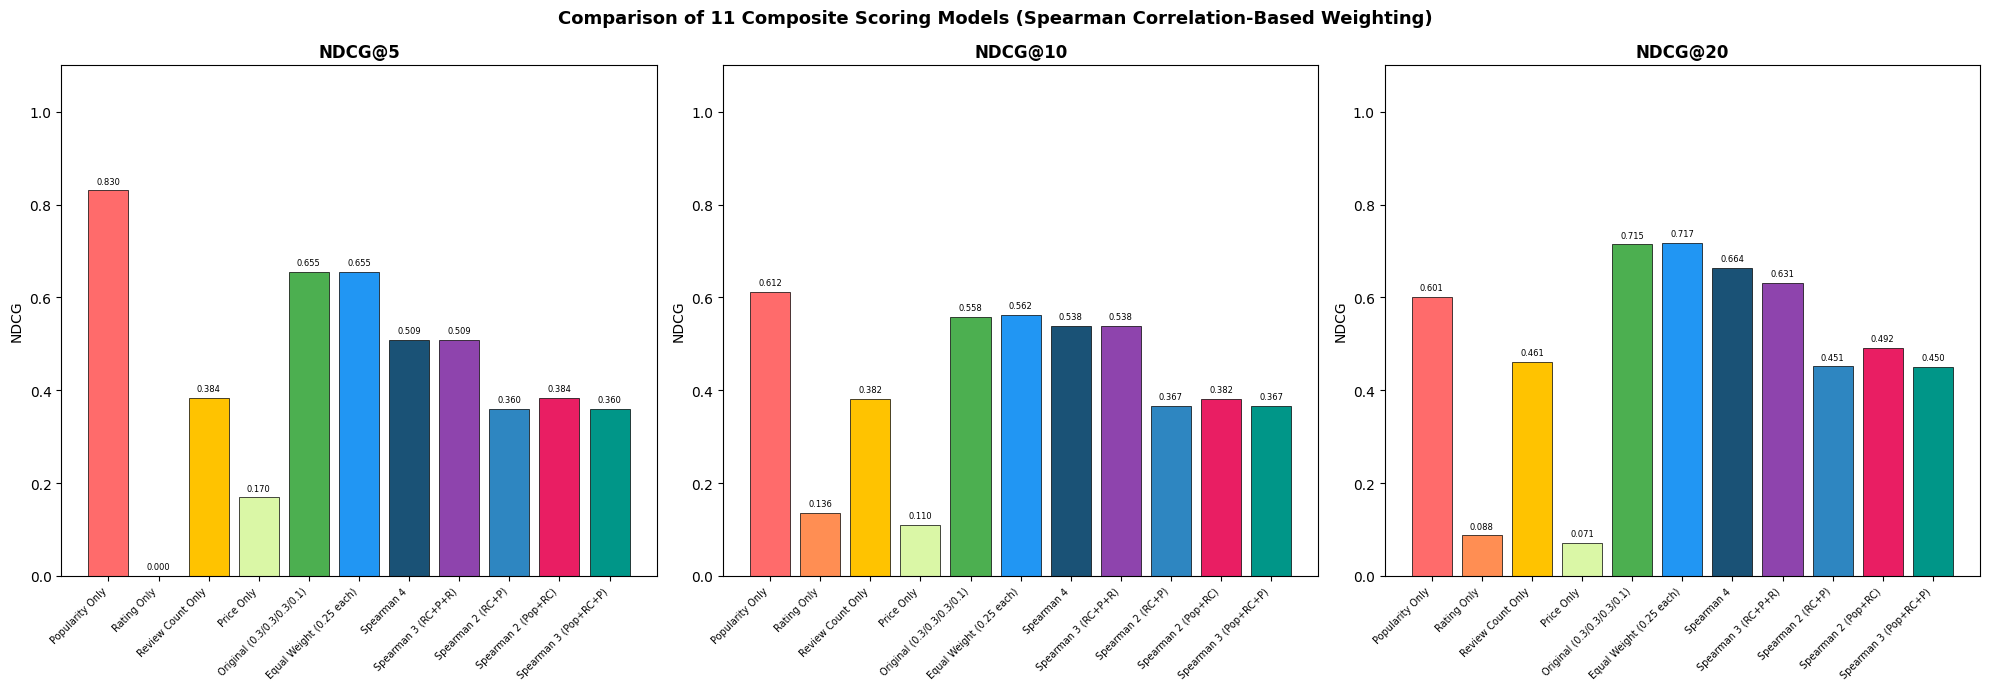

Visualization saved!


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
model_names = [m.replace('CS ','').replace(' Indicators','').replace(' Ind','') for m in df_eval['Model']]
colors = ['#FF6B6B','#FF8E53','#FFC300','#DAF7A6','#4CAF50',
          '#2196F3','#1A5276','#8E44AD','#2E86C1','#E91E63','#009688']

for ax, metric, k in zip(axes, ['NDCG@5','NDCG@10','NDCG@20'], [5,10,20]):
    bars = ax.bar(range(len(model_names)), df_eval[metric], color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(f'NDCG@{k}', fontweight='bold', fontsize=12)
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=7)
    ax.set_ylabel('NDCG')
    ax.set_ylim(0, 1.1)
    for bar, val in zip(bars, df_eval[metric]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=6)

title = 'Comparison of 11 Composite Scoring Models (Spearman Correlation-Based Weighting)'
plt.suptitle(title, fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('cs_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved!")

## 11. Exploratory Data Analysis (EDA)

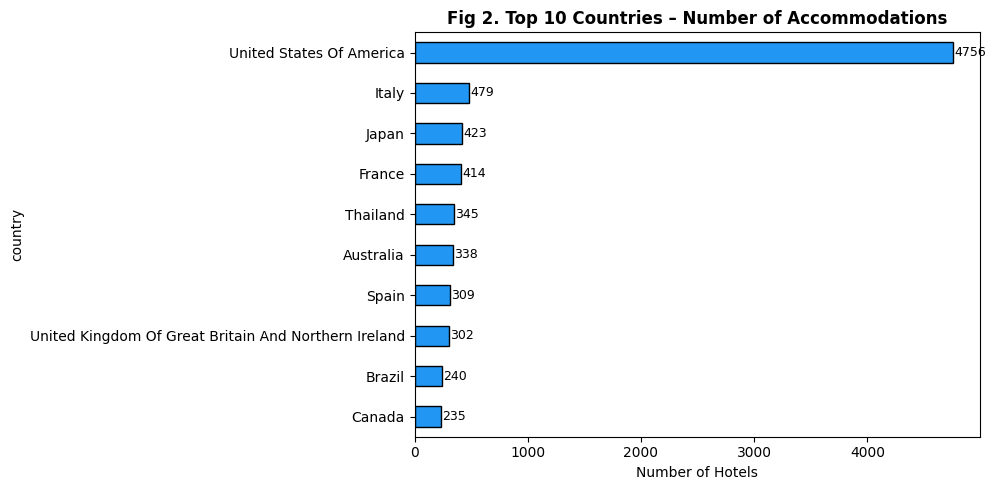

In [16]:
# Fig 2: Top 10 Countries
country_count = df_valid['country'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(10, 5))
country_count.sort_values().plot(kind='barh', ax=ax, color='#2196F3', edgecolor='black')
ax.set_title('Fig 2. Top 10 Countries – Number of Accommodations', fontweight='bold')
ax.set_xlabel('Number of Hotels')
for i, v in enumerate(country_count.sort_values()):
    ax.text(v + 10, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig_country.png', dpi=150, bbox_inches='tight')
plt.show()

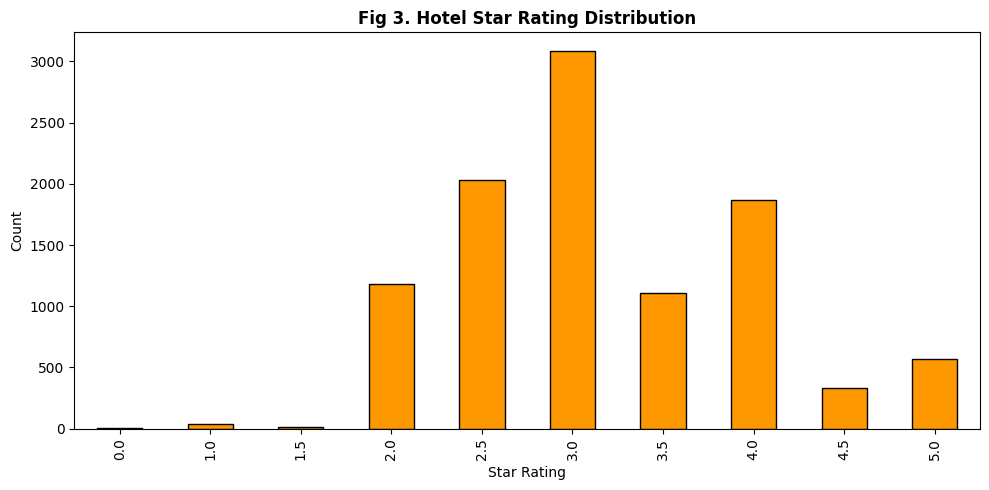

In [17]:
# Fig 3: Star Rating Distribution
fig, ax = plt.subplots(figsize=(10, 5))
df_valid['star_rating'].value_counts().sort_index().plot(kind='bar', ax=ax, color='#FF9800', edgecolor='black')
ax.set_title('Fig 3. Hotel Star Rating Distribution', fontweight='bold')
ax.set_xlabel('Star Rating')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('fig_star.png', dpi=150, bbox_inches='tight')
plt.show()

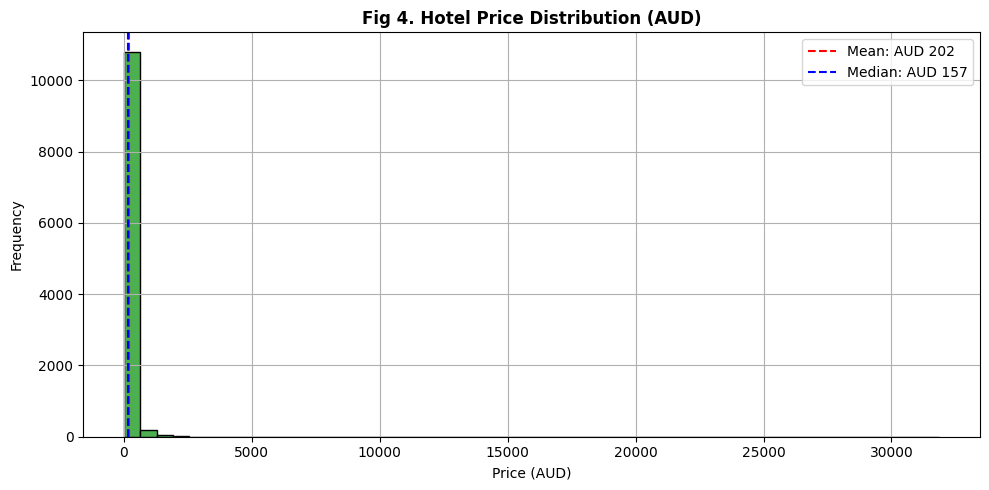

In [18]:
# Fig 4: Price Distribution
fig, ax = plt.subplots(figsize=(10, 5))
df_valid['price_in_aud'].hist(bins=50, ax=ax, color='#4CAF50', edgecolor='black')
ax.axvline(df_valid['price_in_aud'].mean(), color='red', linestyle='--',
           label=f"Mean: AUD {df_valid['price_in_aud'].mean():.0f}")
ax.axvline(df_valid['price_in_aud'].median(), color='blue', linestyle='--',
           label=f"Median: AUD {df_valid['price_in_aud'].median():.0f}")
ax.set_title('Fig 4. Hotel Price Distribution (AUD)', fontweight='bold')
ax.set_xlabel('Price (AUD)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('fig_price.png', dpi=150, bbox_inches='tight')
plt.show()

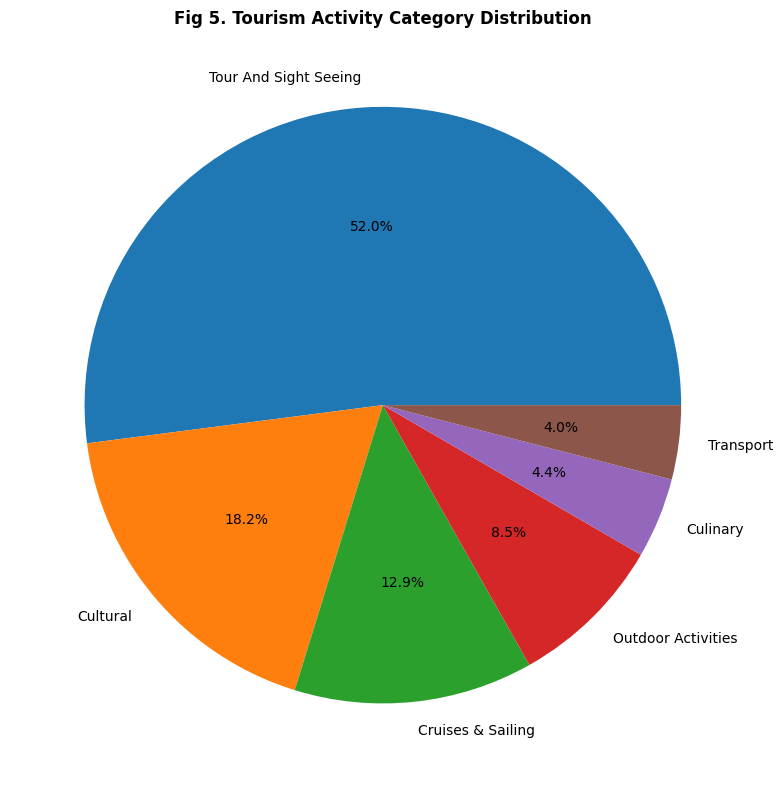

In [19]:
# Fig 5: Activity Category Distribution
cat_split = df_activity['categories'].str.split('|').explode().str.strip()
cat_counts = cat_split.value_counts().head(6)
fig, ax = plt.subplots(figsize=(8, 8))
cat_counts.plot(kind='pie', ax=ax, autopct='%1.1f%%')
ax.set_title('Fig 5. Tourism Activity Category Distribution', fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('fig_activity.png', dpi=150, bbox_inches='tight')
plt.show()

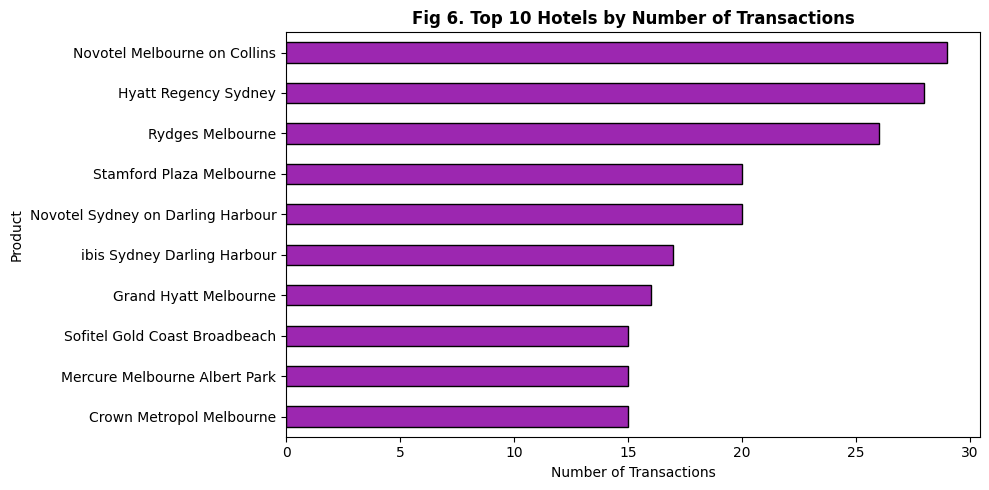

In [20]:
# Fig 6: Top 10 Hotels by Transactions
top_hotels = df_trans.groupby('Product')['Number Transactions'].sum().nlargest(10)
fig, ax = plt.subplots(figsize=(10, 5))
top_hotels.sort_values().plot(kind='barh', ax=ax, color='#9C27B0', edgecolor='black')
ax.set_title('Fig 6. Top 10 Hotels by Number of Transactions', fontweight='bold')
ax.set_xlabel('Number of Transactions')
plt.tight_layout()
plt.savefig('fig_top_hotels.png', dpi=150, bbox_inches='tight')
plt.show()

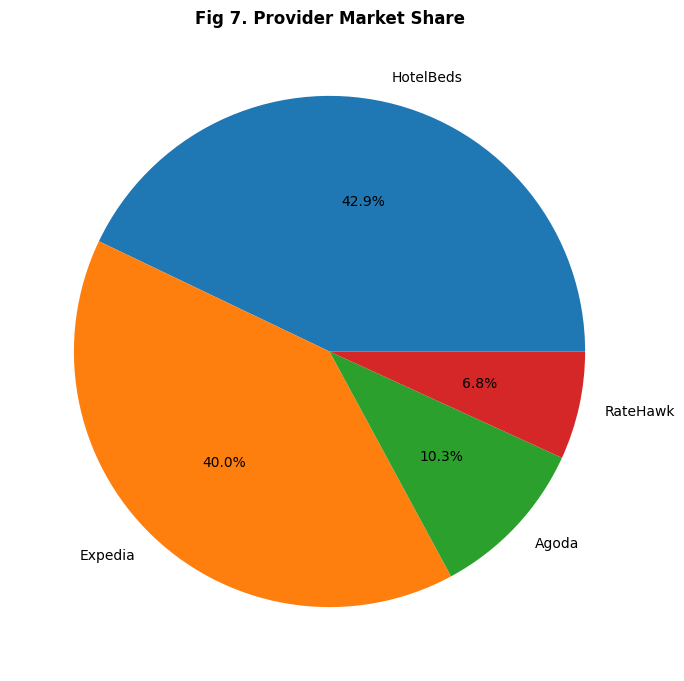

In [21]:
# Fig 7: Provider Market Share
provider_share = df_trans['Property Id'].str.split('-').str[0].value_counts()
fig, ax = plt.subplots(figsize=(7, 7))
provider_share.plot(kind='pie', ax=ax, autopct='%1.1f%%')
ax.set_title('Fig 7. Provider Market Share', fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('fig_provider.png', dpi=150, bbox_inches='tight')
plt.show()

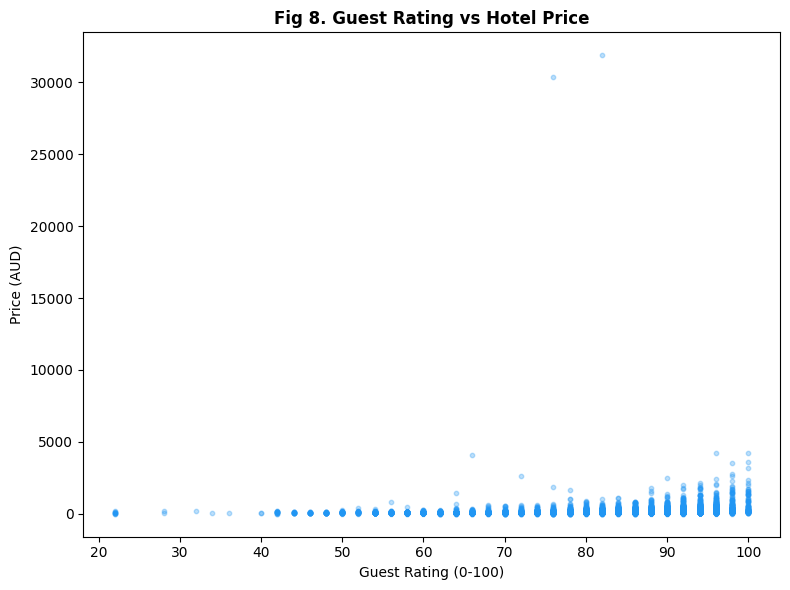

In [22]:
# Fig 8: Guest Rating vs Price
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df_valid['guest_rating_score'], df_valid['price_in_aud'],
           alpha=0.3, color='#2196F3', s=10)
ax.set_title('Fig 8. Guest Rating vs Hotel Price', fontweight='bold')
ax.set_xlabel('Guest Rating (0-100)')
ax.set_ylabel('Price (AUD)')
plt.tight_layout()
plt.savefig('fig_rating_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

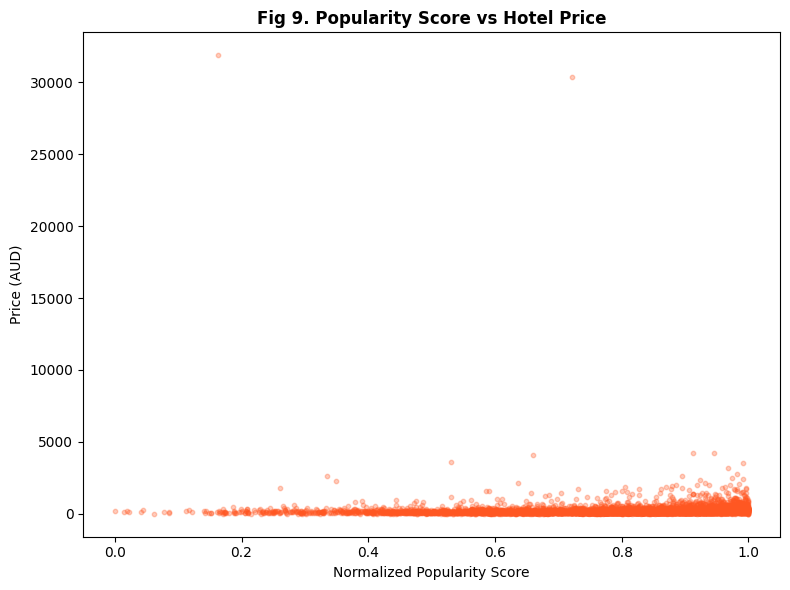

In [23]:
# Fig 9: Normalized Popularity Score vs Price
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df_valid['norm_pop'], df_valid['price_in_aud'],
           alpha=0.3, color='#FF5722', s=10)
ax.set_title('Fig 9. Popularity Score vs Hotel Price', fontweight='bold')
ax.set_xlabel('Normalized Popularity Score')
ax.set_ylabel('Price (AUD)')
plt.tight_layout()
plt.savefig('fig_popularity_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

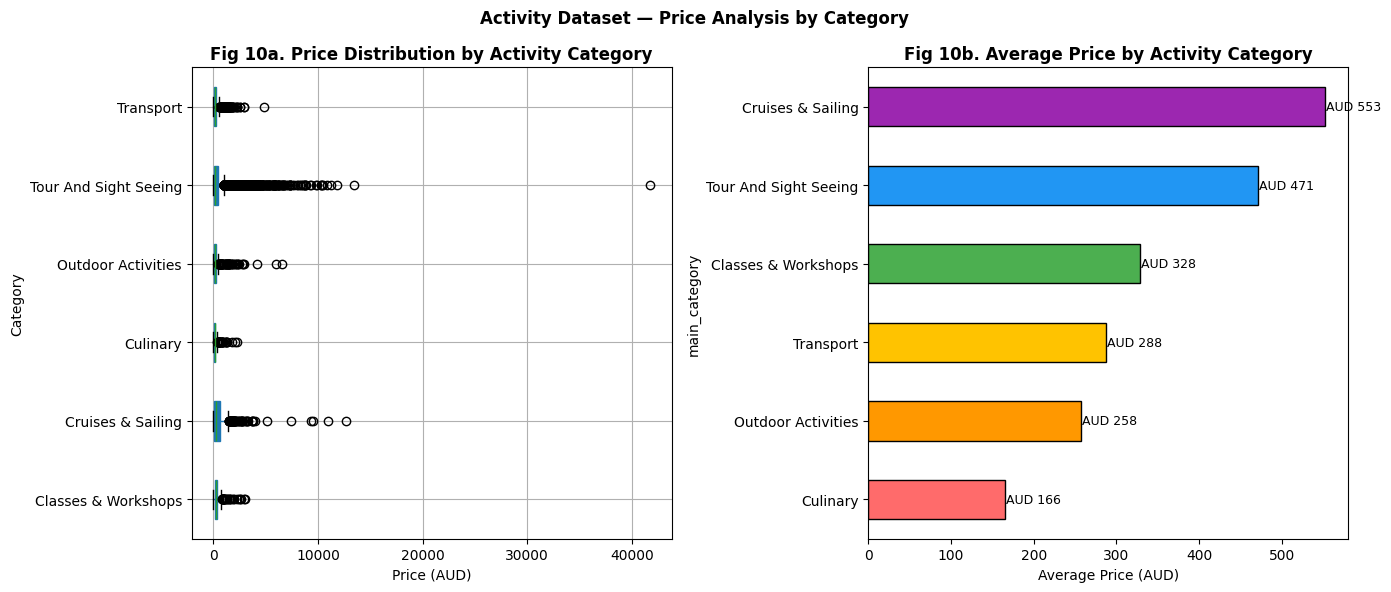


Average price per category:
                         mean  median  count
main_category                               
Classes & Workshops    328.42  207.88    320
Cruises & Sailing      552.77  197.64    628
Culinary               165.83  113.43    548
Outdoor Activities     257.77  115.66    636
Tour And Sight Seeing  471.07  168.36   9489
Transport              287.79  139.54    760


In [24]:
# Fig 10: Activity Price Analysis by Category
df_act = df_activity.copy()
df_act['price_in_aud'] = pd.to_numeric(df_act['price_in_aud'], errors='coerce')
df_act = df_act.dropna(subset=['price_in_aud'])
df_act['main_category'] = df_act['categories'].str.split('|').str[0].str.strip()

top_cats = df_act['main_category'].value_counts().head(6).index.tolist()
df_plot = df_act[df_act['main_category'].isin(top_cats)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df_plot.boxplot(column='price_in_aud', by='main_category', ax=axes[0], vert=False, patch_artist=True)
axes[0].set_title('Fig 10a. Price Distribution by Activity Category', fontweight='bold')
axes[0].set_xlabel('Price (AUD)')
axes[0].set_ylabel('Category')
plt.sca(axes[0])
plt.xticks(rotation=0)

mean_price = df_plot.groupby('main_category')['price_in_aud'].mean().sort_values()
colors_bar = ['#FF6B6B','#FF9800','#FFC300','#4CAF50','#2196F3','#9C27B0']
mean_price.plot(kind='barh', ax=axes[1], color=colors_bar, edgecolor='black')
axes[1].set_title('Fig 10b. Average Price by Activity Category', fontweight='bold')
axes[1].set_xlabel('Average Price (AUD)')
for i, v in enumerate(mean_price):
    axes[1].text(v + 1, i, f'AUD {v:.0f}', va='center', fontsize=9)

plt.suptitle('Activity Dataset — Price Analysis by Category', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('fig_activity_price.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nAverage price per category:")
print(df_plot.groupby('main_category')['price_in_aud'].agg(['mean','median','count']).round(2))

## 12. Top 10 Hotels — CS AHP 4 Indicators

In [25]:
df_top10 = df_valid.nlargest(10, 'cs_spearman4')[
    ['name','country','star_rating','price_in_aud',
     'guest_rating_score','guest_rating_count','cs_spearman4']
].reset_index(drop=True)
df_top10.index += 1
df_top10.columns = ['Hotel Name','Country','Stars','Price (AUD)','Rating','Review Count','CS Score']
display(df_top10)

,Hotel Name,Country,Stars,Price (AUD),Rating,Review Count,CS Score
1,Treasure Island - TI Las Vegas Hotel & Casino,United States Of America,4.0,59.53,84.0,27402.0,0.964364
2,Luxor Hotel and Casino,United States Of America,3.5,25.30,78.0,27408.0,0.951385
3,The Venetian Resort Las Vegas,United States Of America,5.0,173.81,92.0,16236.0,0.862820
4,"Circus Circus Hotel, Casino & Theme Park",United States Of America,3.0,12.10,68.0,16228.0,0.810700
5,The LINQ Hotel & Casino – A Caesars Rewards De...,United States Of America,4.0,12.29,76.0,13422.0,0.798547
6,Wynn Las Vegas,United States Of America,5.0,202.65,92.0,9870.0,0.795069
7,Tropicana Atlantic City – A Caesars Rewards De...,United States Of America,3.5,51.94,72.0,13417.0,0.785756
8,Caesars Palace,United States Of America,4.5,196.32,78.0,11605.0,0.782654
9,Tuscany Suites & Casino,United States Of America,3.5,36.29,90.0,7309.0,0.763984
10,"Virgin Hotel Las Vegas, Curio Collection by Hi...",United States Of America,4.5,92.89,88.0,7024.0,0.756303
